<center style="border-radius:10px;
padding: 3rem 2rem;
border: 3px solid #F54257;
">
<h1 style="color:#F54257; 
font-size:3.0rem;
margin:0;
">KITTI Object Detection</h1>
<h2 style="color:#F54257; 
font-size:2.0rem;
margin-top:1rem;
margin-bottom:2.5rem;
">Late Fusion
</h2>
</center>

In [1]:
!pip install ultralytics -q
!pip install opencv-python-headless -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00


In [2]:
import os
import cv2
import pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
import json
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
DATASET_ROOT = Path('/kaggle/input/kitti-3d-object-detection-dataset/training')
IMG_DIR = DATASET_ROOT / 'image_2'
VELO_DIR = DATASET_ROOT / 'velodyne'
CALIB_DIR = DATASET_ROOT / 'calib'
LABEL_DIR = DATASET_ROOT / 'label_2'  # metrics calculation

MODEL_PATH = '/kaggle/input/rtvisiononly2/pytorch/default/1/best.pt'

if IMG_DIR.exists() and VELO_DIR.exists():
    print(f"images at {IMG_DIR}")
    print(f"LiDAR at {VELO_DIR}")
    print(f"Calib at {CALIB_DIR}")
else:
    print("could not find subfolders.")

if Path(MODEL_PATH).exists():
    print("ye")
else:
    print("ne")

images at /kaggle/input/kitti-3d-object-detection-dataset/training/image_2
LiDAR at /kaggle/input/kitti-3d-object-detection-dataset/training/velodyne
Calib at /kaggle/input/kitti-3d-object-detection-dataset/training/calib
ye


In [4]:
CONF_THRESH = 0.5       # YOLO Confidence Threshold
IOU_THRESH = 0.5        # Fusion Match Threshold (Projected LiDAR vs Camera)
EVAL_SPLIT_RATIO = 0.2  # Use 20% of data for validation/metrics
LIDAR_EPS = 0.8         # DBSCAN Radius (meters)
LIDAR_MIN_SAMPLES = 15  # DBSCAN Density

with open('/kaggle/input/kitti-dataset-yolo-format/classes.json','r') as f:
    classes = json.load(f)

print(classes)

# Class Mapping (KITTI String -> YOLO ID)
# needs to be same as vision only model
CLASS_MAP = classes
CLASS_MAP_INV = {v: k for k, v in CLASS_MAP.items()} # for visualizer


{'Car': 0, 'Pedestrian': 1, 'Van': 2, 'Cyclist': 3, 'Truck': 4, 'Misc': 5, 'Tram': 6, 'Person_sitting': 7}


# Helper Classes
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>

In [5]:
class Calibration:
    def __init__(self, calib_filepath):
        self.calib = self._read_calib(calib_filepath)
        self.P2 = self.calib['P2'].reshape(3, 4)
        
        # Expand R0_rect to 4x4
        self.R0_rect = np.eye(4)
        self.R0_rect[:3, :3] = self.calib['R0_rect'].reshape(3, 3)
        
        # Expand Tr_velo_to_cam to 4x4
        self.Tr_velo_to_cam = np.eye(4)
        self.Tr_velo_to_cam[:3, :4] = self.calib['Tr_velo_to_cam'].reshape(3, 4)

    def _read_calib(self, filepath):
        data = {}
        with open(filepath, 'r') as f:
            for line in f:
                if ':' not in line: continue
                key, val = line.split(':', 1)
                try:
                    data[key] = np.array([float(x) for x in val.split()])
                except ValueError:
                    pass
        return data

    def velo_to_img(self, pts_3d):
        """Projects 3D LiDAR points to 2D image pixels."""
        # 1. Convert to Homogenous
        pts_3d_hom = np.hstack((pts_3d, np.ones((pts_3d.shape[0], 1))))
        
        # 2. Transform: Velo -> Cam -> Rect -> Image
        pts_3d_cam = np.dot(pts_3d_hom, self.Tr_velo_to_cam.T)
        pts_3d_rect = np.dot(pts_3d_cam, self.R0_rect.T)
        pts_2d_hom = np.dot(pts_3d_rect, self.P2.T)
        
        # 3. Normalize
        pts_2d = pts_2d_hom[:, :2] / pts_2d_hom[:, 2:3]
        return pts_2d, pts_3d_rect[:, 2] # Return (u,v) and Depth

def compute_iou(boxA, boxB):
    """Intersection over Union for 2D boxes"""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

In [6]:
class LateFusionPipeline:
    def __init__(self, model_path):
        print(f"Loading YOLO model from: {model_path}")
        self.model = YOLO(model_path)
        # DBSCAN: eps=0.8m, min_samples=15 (Adjusted for vehicle clusters)
        self.clusterer = DBSCAN(eps=0.8, min_samples=15)

    def run_camera(self, img):
        """Returns numpy array: [x1, y1, x2, y2, conf, cls]"""
        # Lower confidence slightly to catch more candidates, we filter later
        results = self.model(img, verbose=False, conf=0.25) 
        
        if len(results) > 0 and results[0].boxes is not None:
            return results[0].boxes.data.cpu().numpy()
        return []

    def run_lidar(self, bin_path, calib, img_shape):
        """
        Standard DBSCAN clustering + 2D Projection
        """
        # 1. Load Point Cloud
        points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
        
        # 2. ROI Filter (Forward 50m, remove ground)
        mask = (points[:, 0] > 0) & (points[:, 0] < 50) & \
               (points[:, 2] > -1.4) & (np.abs(points[:, 1]) < 20)
        roi = points[mask, :3]
        
        if len(roi) == 0: return []

        # 3. Cluster
        labels = self.clusterer.fit_predict(roi)
        unique_labels = set(labels)
        
        lidar_objs = []
        for lbl in unique_labels:
            if lbl == -1: continue # Noise
            
            cluster = roi[labels == lbl]
            
            # 4. Project
            pts_2d, depths = calib.velo_to_img(cluster)
            
            # Filter projections inside valid image area
            valid = (depths > 0) & \
                    (pts_2d[:,0] >= 0) & (pts_2d[:,0] < img_shape[1]) & \
                    (pts_2d[:,1] >= 0) & (pts_2d[:,1] < img_shape[0])
            
            if np.sum(valid) < 5: continue
            
            valid_pts = pts_2d[valid]
            u_min, v_min = valid_pts.min(axis=0)
            u_max, v_max = valid_pts.max(axis=0)
            
            lidar_objs.append({
                'bbox': [u_min, v_min, u_max, v_max],
                'depth': np.mean(depths[valid])
            })
            
        return lidar_objs

    def fuse(self, cam_boxes, lidar_objs):
        """
        IMPROVED FUSION LOGIC (Union):
        1. Match Camera <-> LiDAR (Keep FUSED)
        2. If No Match -> Keep Camera IF confidence is high (CAMERA_ONLY)
        """
        fused_preds = []
        
        # Thresholds
        MATCH_IOU_THRESH = 0.25  # Relaxed: Boxes don't need to overlap perfectly
        HIGH_CONF_THRESH = 0.60  # Strict: Only keep unmatched camera if very sure
        
        for box in cam_boxes:
            c_rect = box[:4]
            cls_id = int(box[5])
            conf = box[4]
            
            best_iou = 0
            match = None
            
            # Find best LiDAR match
            for l_obj in lidar_objs:
                iou = compute_iou(c_rect, l_obj['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    match = l_obj
            
            # DECISION LOGIC
            if best_iou > MATCH_IOU_THRESH:
                # Scenario 1: CONFIRMED BY LIDAR
                fused_preds.append({
                    'bbox': c_rect,
                    'class': cls_id,
                    'conf': conf,
                    'depth': match['depth'],
                    'type': 'FUSED'
                })
            
            elif conf > HIGH_CONF_THRESH:
                # Scenario 2: MISSED BY LIDAR, BUT HIGH CONFIDENCE CAMERA
                # (Likely a distant car or black car that LiDAR missed)
                fused_preds.append({
                    'bbox': c_rect,
                    'class': cls_id,
                    'conf': conf,
                    'depth': -1,  # Unknown depth
                    'type': 'CAMERA_ONLY'
                })
                
        return fused_preds

# Helper Functions
## Evaluation Metrics
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>

In [7]:
def load_gt_boxes(label_path):
    """Parses KITTI label file. Returns list [x1, y1, x2, y2, cls_id]"""
    gt = []
    if not os.path.exists(label_path): return []
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.split()
            cls_str = parts[0]
            
            if cls_str not in CLASS_MAP: continue # Skip DontCare, Misc, etc.
            
            # KITTI 2D Box (Left, Top, Right, Bottom)
            bbox = [float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])]
            cls_id = CLASS_MAP[cls_str]
            
            gt.append(bbox + [cls_id])
    return gt

def calculate_metrics(predictions, ground_truths):
    """Matches FUSED predictions to Ground Truth"""
    tp, fp, fn = 0, 0, 0
    matched_gt = set()
    
    for p in predictions:
        p_box = p['bbox']
        p_cls = p['class']
        
        best_iou = 0
        best_idx = -1
        
        # Try to find a Ground Truth match
        for i, gt in enumerate(ground_truths):
            gt_box = gt[:4]
            gt_cls = gt[4]
            
            if p_cls != gt_cls: continue
            
            iou = compute_iou(p_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_idx = i
                
        # Hit?
        if best_iou >= 0.5 and best_idx not in matched_gt:
            tp += 1
            matched_gt.add(best_idx)
        else:
            fp += 1
            
    fn = len(ground_truths) - len(matched_gt)
    return tp, fp, fn


def compute_ap(recalls, precisions):
    """
    Computes AP from recall and precision curves.
    Uses the 'All-Points' integration (area under the PR curve).
    """
    # Append sentinel values to ensure curve starts/ends correctly
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))

    # Compute the precision envelope (ensure precision is non-increasing)
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Find points where recall changes
    idx = np.where(mrec[1:] != mrec[:-1])[0]

    # Calculate AP as sum of Area = (Change in Recall) * Precision
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return ap

# Pipeline Driver
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>

In [8]:
# 1. Prepare Split
all_images = sorted(list(IMG_DIR.glob('*.png')))
split_idx = int(len(all_images) * (1 - EVAL_SPLIT_RATIO))
test_images = all_images[split_idx:] 

print(f"Total Test Frames: {len(test_images)}")

# 2. Init Pipeline
pipeline = LateFusionPipeline(MODEL_PATH)

# 3. Initialize Metrics
all_detection_results = [] # Stores [confidence, is_tp] for every detection
total_gt_count = 0         # Needed for Recall calculation
total_tp, total_fp, total_fn = 0, 0, 0

print("Running Fusion Evaluation...")
for img_path in tqdm(test_images):
    fid = img_path.stem
    
    bin_path = VELO_DIR / f"{fid}.bin"
    calib_path = CALIB_DIR / f"{fid}.txt"
    label_path = LABEL_DIR / f"{fid}.txt"
    
    if not bin_path.exists() or not calib_path.exists(): continue
    
    # A. Run Fusion Pipeline
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    calib = Calibration(calib_path)
    
    cam_boxes = pipeline.run_camera(img_rgb)
    lidar_objs = pipeline.run_lidar(str(bin_path), calib, img.shape)
    fused_preds = pipeline.fuse(cam_boxes, lidar_objs)
    
    # B. Filter Logic: Accept FUSED and high-confidence CAMERA_ONLY
    valid_preds = [p for p in fused_preds if p['type'] in ['FUSED', 'CAMERA_ONLY']]
    
    # C. Load Ground Truth
    gt_boxes = load_gt_boxes(label_path)
    total_gt_count += len(gt_boxes)
    
    # D. Detailed Matching for AP (Confidence-based)
    # Sort detections by confidence for this frame to match best candidates first
    frame_preds = sorted(valid_preds, key=lambda x: x['conf'], reverse=True)
    matched_gt = set()
    
    for p in frame_preds:
        best_iou = 0
        best_idx = -1
        
        for i, gt in enumerate(gt_boxes):
            if p['class'] == gt[4]: # Class match
                iou = compute_iou(p['bbox'], gt[:4])
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
        
        if best_iou >= 0.5 and best_idx not in matched_gt:
            all_detection_results.append([p['conf'], 1]) # True Positive
            matched_gt.add(best_idx)
            total_tp += 1
        else:
            all_detection_results.append([p['conf'], 0]) # False Positive
            total_fp += 1
            
    total_fn += (len(gt_boxes) - len(matched_gt))

Total Test Frames: 1497
Loading YOLO model from: /kaggle/input/rtvisiononly2/pytorch/default/1/best.pt
Running Fusion Evaluation...


100%|██████████| 1497/1497 [20:56<00:00,  1.19it/s]


# Validation
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>


 FINAL LATE FUSION RESULTS
Frames Evaluated : 1497
Total GT Objects : 7991
TP: 6079 | FP: 683 | FN: 1912
----------------------------------------
Average Precision: 0.7486
Precision        : 89.90%
Recall           : 76.07%
F1 Score         : 0.8241


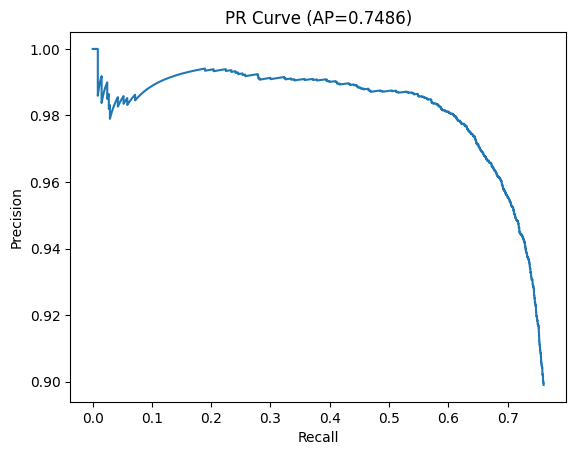

In [9]:
# Calculate AP using the all_detection_results list
all_detection_results = np.array(all_detection_results)
if len(all_detection_results) > 0:
    # Sort ALL detections across ALL frames by confidence
    indices = np.argsort(-all_detection_results[:, 0])
    sorted_results = all_detection_results[indices]
    
    # Compute cumulative Precision and Recall
    tp_cumsum = np.cumsum(sorted_results[:, 1])
    fp_cumsum = np.cumsum(1 - sorted_results[:, 1])
    
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
    recalls = tp_cumsum / (total_gt_count + 1e-6)
    
    # Call your compute_ap function
    final_ap = compute_ap(recalls, precisions)
else:
    final_ap = 0.0

# Calculate standard summary metrics
precision = total_tp / (total_tp + total_fp + 1e-6)
recall = total_tp / (total_tp + total_fn + 1e-6)
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("\n" + "="*40)
print(" FINAL LATE FUSION RESULTS")
print("="*40)
print(f"Frames Evaluated : {len(test_images)}")
print(f"Total GT Objects : {total_gt_count}")
print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn}")
print("-" * 40)
print(f"Average Precision: {final_ap:.4f}")
print(f"Precision        : {precision:.2%}")
print(f"Recall           : {recall:.2%}")
print(f"F1 Score         : {f1:.4f}")
print("="*40)

# Optional: Plot the PR Curve
plt.plot(recalls, precisions)
plt.title(f"PR Curve (AP={final_ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Visualization
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>

In [10]:
class FusionVisualizer:
    def __init__(self, class_map):
        self.class_map = {v: k for k, v in class_map.items()} # Invert ID->Name
        self.colors = {
            'FUSED': (0, 255, 0),       # Green
            'CAMERA_ONLY': (0, 255, 255), # Cyan (Yellow-ish in RGB, Cyan in BGR)
            'LIDAR_RAW': (0, 0, 255),   # Red
            'GT': (255, 255, 0)         # Blue-ish (Yellow in BGR)
        }

    def draw_box(self, img, box, color, label=None, thickness=2):
        x1, y1, x2, y2 = map(int, box[:4])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        if label:
            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img, (x1, y1 - 20), (x1 + w, y1), color, -1)
            cv2.putText(img, label, (x1, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    def visualize(self, img, preds, gt_boxes=None, lidar_raw=None):
        vis_img = img.copy()
        
        # 1. Draw Raw LiDAR clusters (faint red) - helps debug DBSCAN
        if lidar_raw:
            for l_obj in lidar_raw:
                self.draw_box(vis_img, l_obj['bbox'], self.colors['LIDAR_RAW'], thickness=1)

        # 2. Draw Ground Truth (Yellow)
        if gt_boxes:
            for gt in gt_boxes:
                cls_name = "GT" 
                self.draw_box(vis_img, gt, self.colors['GT'], label=cls_name, thickness=2)

        # 3. Draw Predictions (Green for Fused, Cyan for Cam-Only)
        for p in preds:
            color = self.colors.get(p['type'], (255, 255, 255))
            cls_name = self.class_map.get(p['class'], 'Obj')
            conf_str = f"{p['conf']:.2f}"
            
            # Label format: "Car 0.85 [FUSED]"
            label = f"{cls_name} {conf_str}"
            self.draw_box(vis_img, p['bbox'], color, label=label, thickness=2)

        return vis_img

Visualizing Frame ID: 006894


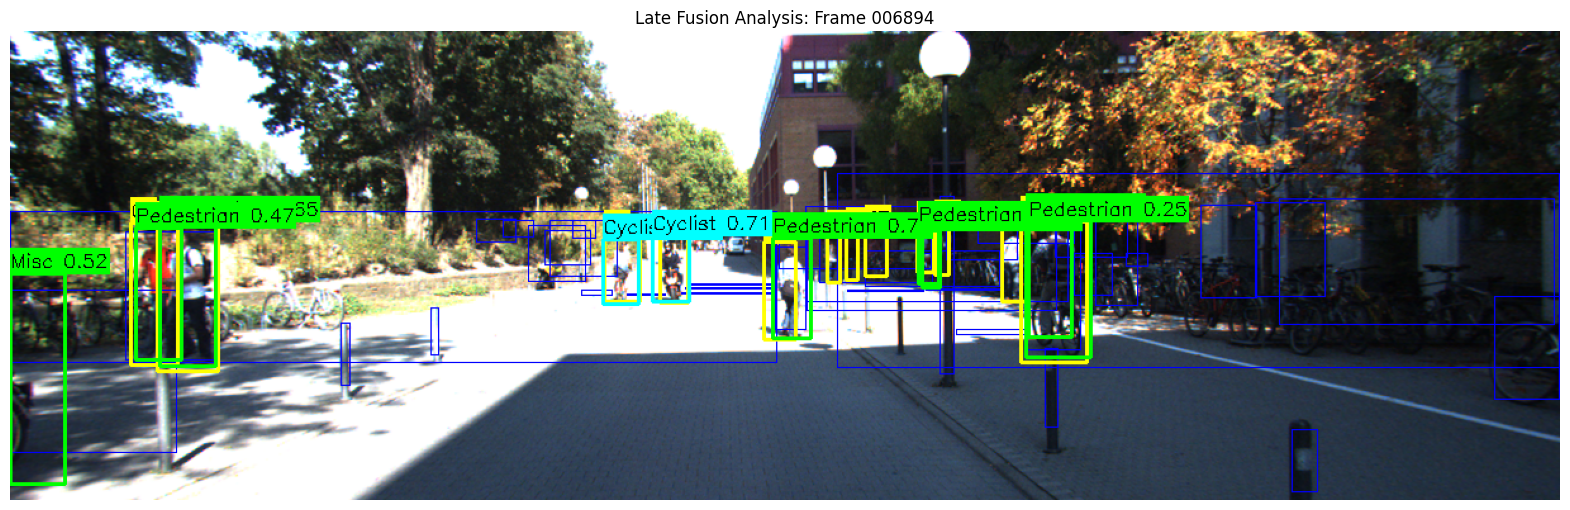

Found 10 objects total.
 - [CAMERA_ONLY] Cyclist: Conf 0.80, Depth: Unknown
 - [FUSED] Pedestrian: Conf 0.79, Depth: 15.82m
 - [FUSED] Cyclist: Conf 0.77, Depth: 12.19m
 - [CAMERA_ONLY] Cyclist: Conf 0.71, Depth: Unknown
 - [FUSED] Pedestrian: Conf 0.65, Depth: 12.15m
 - [FUSED] Misc: Conf 0.52, Depth: 6.52m
 - [FUSED] Pedestrian: Conf 0.47, Depth: 12.15m
 - [FUSED] Pedestrian: Conf 0.44, Depth: 37.26m
 - [FUSED] Pedestrian: Conf 0.31, Depth: 37.26m
 - [FUSED] Pedestrian: Conf 0.25, Depth: 12.19m


In [11]:
# 1. Choose random image from test images
random_img_path = random.choice(test_images)
fid = random_img_path.stem 

print(f"Visualizing Frame ID: {fid}")

# 2. Setup Paths
bin_path = VELO_DIR / f"{fid}.bin"
calib_path = CALIB_DIR / f"{fid}.txt"
label_path = LABEL_DIR / f"{fid}.txt"

# 3. Run Pipeline for this single image
img = cv2.imread(str(IMG_DIR / f"{fid}.png"))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
calib = Calibration(calib_path)

# Execute detection and fusion
cam_boxes = pipeline.run_camera(img_rgb)
lidar_objs = pipeline.run_lidar(str(bin_path), calib, img.shape)
fused_preds = pipeline.fuse(cam_boxes, lidar_objs)
gt_boxes = load_gt_boxes(label_path)

# 4. Use the Visualizer
viz = FusionVisualizer(CLASS_MAP)
# Generate the debug image with all layers (GT, Preds, and Raw LiDAR for debugging)
debug_img = viz.visualize(img_rgb, fused_preds, gt_boxes, lidar_objs)

# 5. Display
plt.figure(figsize=(20, 10))
plt.imshow(debug_img)
plt.title(f"Late Fusion Analysis: Frame {fid}")
plt.axis('off')
plt.show()

# Print text summary for clarity
print(f"Found {len(fused_preds)} objects total.")
for p in fused_preds:
    depth_str = f"{p['depth']:.2f}m" if p['depth'] > 0 else "Unknown"
    print(f" - [{p['type']}] {CLASS_MAP_INV[p['class']]}: Conf {p['conf']:.2f}, Depth: {depth_str}")